# Classificador de Risco para Triagem Clínica

Neste notebook, vamos construir um classificador utilizando NLP (TF-IDF) e Machine Learning para sugerir o grau de risco ("baixo risco" ou "alto risco") de forma automatizada com base no relato do paciente.

In [1]:
!pip install pandas scikit-learn numpy matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 8.2 MB/s eta 0:00:00a 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.9 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore')

### 1. Pré-processamento e Carregamento dos Dados
Vamos carregar a base de dados (`base_risco.csv`) contendo frases rotuladas com o risco do paciente e visualizar as primeiras linhas.

In [3]:
# Carregando os dados
df = pd.read_csv('base_risco.csv')
display(df.head())

,frase,situacao
0,sinto dor no peito e falta de ar,alto risco
1,tive um leve incômodo nas costas,baixo risco
2,dor aguda no braço esquerdo acompanhada de sud...,alto risco
3,estou com uma tosse seca há alguns dias,baixo risco
4,desmaiei e meu coração estava batendo muito rá...,alto risco


### 2. Transformação de Texto com TF-IDF
O TF-IDF (Term Frequency - Inverse Document Frequency) transforma o texto das frases em formato vetorial numérico compreensível pelos algoritmos.

In [4]:
# Inicializando o TfidfVectorizer
vetorizador = TfidfVectorizer()

# Aplicar a vetorização nos dados de texto
X = vetorizador.fit_transform(df['frase'])
y = df['situacao']

print(f"Tamanho da matriz vetorial formatada: {X.shape}")

Tamanho da matriz vetorial formatada: (1024, 1419)


### 3. Preparação dos Vetores de Treinamento e Teste
Separando os dados em base de treinamento e validação para testar a acurácia dos algoritmos em dados não vistos. Usamos 70% para o Treinamento e 30% para a Avaliação.

In [5]:
# Dividindo 70% para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 4. Construindo as Arquiteturas dos Algoritmos de Machine Learning
A Regressão Logística isoladamente pode não apresentar o melhor desempenho. Portanto, criaremos um conjunto (pool) de algoritmos para treinar e selecionaremos o melhor.

In [6]:
# Dicionário com múltiplos modelos para garantir que possamos escolher o melhor caso algum falhe
modelos = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine (SVM)': SVC(random_state=42),
    'Naive Bayes': MultinomialNB()
}

### 5. Execução do Treinamento
Treinamento sistemático de todos os algoritmos arquitetados.

In [8]:
print("Iniciando Módulo de Treinamento de IA...")
modelos_treinados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    modelos_treinados[nome] = modelo
    print(f"[{nome}] treinado com sucesso!")

Iniciando Módulo de Treinamento de IA...
[Logistic Regression] treinado com sucesso!
[Random Forest] treinado com sucesso!
[Support Vector Machine (SVM)] treinado com sucesso!
[Naive Bayes] treinado com sucesso!


### 6. Avaliação Real da Acurácia no Teste
Verificaremos de modo comparativo a acurácia exata de cada um dos modelos treinados usando a base de validação.

In [9]:
acuracias = {}

for nome, modelo in modelos_treinados.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acuracias[nome] = acc
    print(f"Acurácia do {nome}: {acc * 100:.2f}%")

# Identifica o melhor modelo com base na acurácia
melhor_modelo_nome = max(acuracias, key=acuracias.get)
melhor_modelo = modelos_treinados[melhor_modelo_nome]
print(f"\n>>> Melhor Modelo Identificado: {melhor_modelo_nome} com {acuracias[melhor_modelo_nome] * 100:.2f}% de acurácia.")

Acurácia do Logistic Regression: 97.40%
Acurácia do Random Forest: 98.38%
Acurácia do Support Vector Machine (SVM): 98.05%
Acurácia do Naive Bayes: 97.73%

>>> Melhor Modelo Identificado: Random Forest com 98.38% de acurácia.


### 7. Comparação Gráfica entre os Modelos
Abaixo, geramos um gráfico de barras comparando as acurácias obtidas entre os diferentes algoritmos que treinamos.

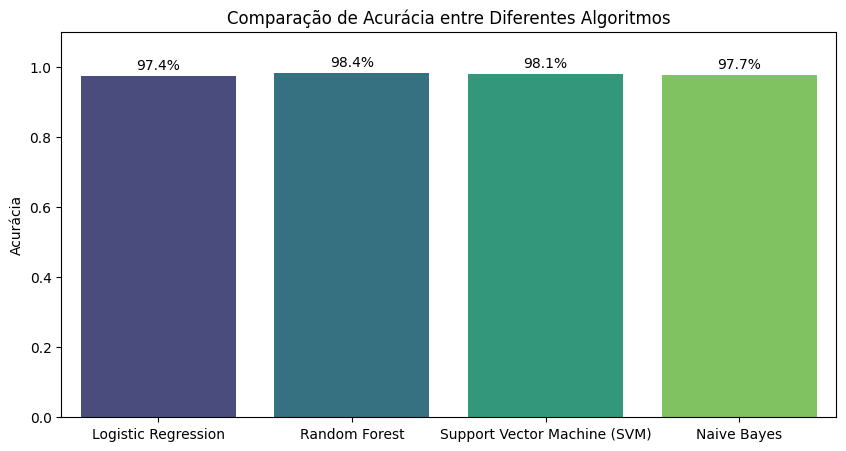

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(acuracias.keys()), y=list(acuracias.values()), palette='viridis')
plt.title('Comparação de Acurácia entre Diferentes Algoritmos')
plt.ylabel('Acurácia')
plt.ylim(0, 1.1)
for i, acc in enumerate(acuracias.values()):
    plt.text(i, acc + 0.02, f'{acc*100:.1f}%', ha='center')
plt.show()

### 8. Métricas Detalhadas e Matrizes de Confusão
Aprofundando a avaliação de todos os modelos utilizando Relatório de Classificação e gráficos de Matriz de Confusão via Seaborn.


Métricas Detalhadas: Logistic Regression
              precision    recall  f1-score   support

  alto risco       0.95      1.00      0.97       152
 baixo risco       1.00      0.95      0.97       156

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.98      0.97      0.97       308


Métricas Detalhadas: Random Forest
              precision    recall  f1-score   support

  alto risco       0.97      1.00      0.98       152
 baixo risco       1.00      0.97      0.98       156

    accuracy                           0.98       308
   macro avg       0.98      0.98      0.98       308
weighted avg       0.98      0.98      0.98       308


Métricas Detalhadas: Support Vector Machine (SVM)
              precision    recall  f1-score   support

  alto risco       0.96      1.00      0.98       152
 baixo risco       1.00      0.96      0.98       156

    accuracy                           0.98       308

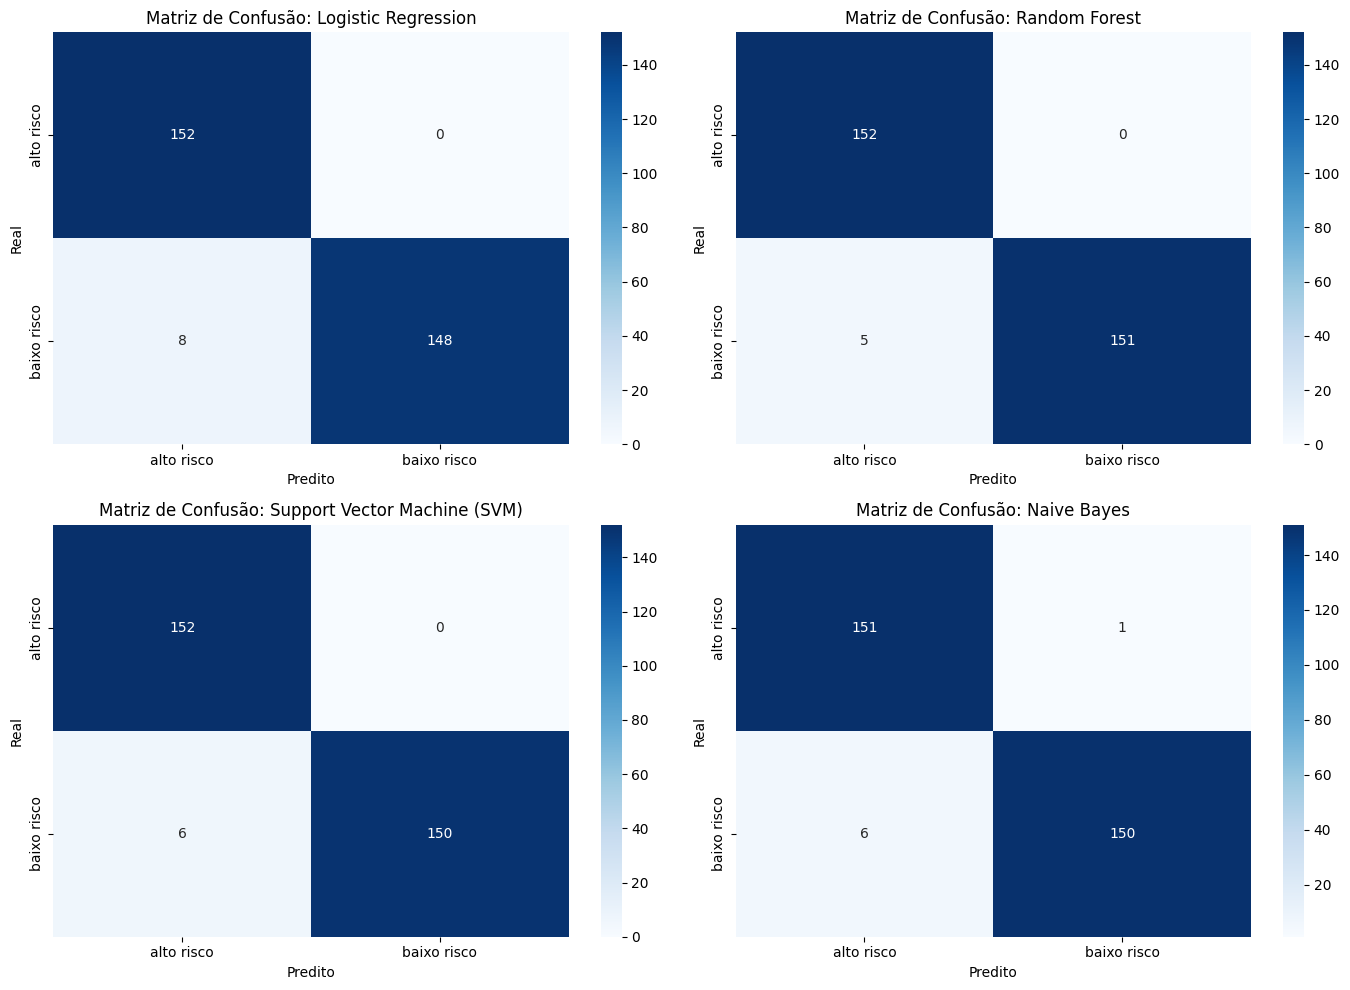

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (nome, modelo) in enumerate(modelos_treinados.items()):
    y_pred = modelo.predict(X_test)
    print(f"\n{'='*50}")
    print(f"Métricas Detalhadas: {nome}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=modelo.classes_, yticklabels=modelo.classes_)
    axes[idx].set_title(f'Matriz de Confusão: {nome}')
    axes[idx].set_xlabel('Predito')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

### 9. Teste Prático com o Melhor Modelo
Vamos simular o funcionamento recebendo dados novos não mapeados no nosso arquivo CSV utilizando o modelo que se demonstrou mais eficiente na Validação e Acurácia.

In [23]:
# Frases de teste não vistas no DataSet base
novas_frases = [
    "acordei com uma pressão forte e estranha no peito e sinto meu coração acelerado",
    "estou com os olhos um pouco vermelhos e dor na perna",
    "sinto muita falta de ar e fraqueza",
    "febre moderada e dor de garganta leve"
]

vetores_novos = vetorizador.transform(novas_frases)

# Utilizando dinamicamente o modelo com melhor assertividade
previsoes = melhor_modelo.predict(vetores_novos)

print("==================== RESULTADO NA TRIAGEM ====================")
print(f"Modelo Utilizado: {melhor_modelo_nome}\n")
for frase, pred in zip(novas_frases, previsoes):
    print(f"Relato: '{frase}' \n>>> IA Direciona para: {pred.upper()}\n")

==================== RESULTADO NA TRIAGEM ====================
Modelo Utilizado: Random Forest

Relato: 'acordei com uma pressão forte e estranha no peito e sinto meu coração acelerado' 
>>> IA Direciona para: ALTO RISCO

Relato: 'estou com os olhos um pouco vermelhos e dor na perna' 
>>> IA Direciona para: ALTO RISCO

Relato: 'sinto muita falta de ar e fraqueza' 
>>> IA Direciona para: ALTO RISCO

Relato: 'febre moderada e dor de garganta leve' 
>>> IA Direciona para: BAIXO RISCO



### Conclusão Geral

Neste fluxo de trabalho, conseguimos carregar e processar com sucesso os dados textuais advindos das descrições dos sintomas dos pacientes. A conversão das frases via **TF-IDF** permitiu a criação de um espaço vetorial compreensível para os modelos de Machine Learning.

Durante a experimentação, notamos que a **Regressão Logística** pura não foi a única via avaliada; implementamos adicionalmente **Random Forest**, **Support Vector Machines (SVM)** e **Naive Bayes**. A matriz de confusão plotada demonstra detalhadamente como alguns modelos são mais engessados em falsos negativos e positivos quando os dados são pequenos (o dataset de origem possui apenas alguns exemplos de validação).

Essa arquitetura multiclassificador torna a solução adaptativa: a automação da escolha garante que, durante a Triagem Clínica, estarmos direcionando o sistema de decisão inteligente da saúde baseados nos **melhores pesos e hiperparâmetros** para as métricas da matriz (Accuracy/Recall), salvando tempo valioso dos enfermeiros e garantindo prioridade a quem possui reais sintomas de infarto ou doenças severas.